# Machine Learning Model for Gentrification - Random Forest Classifier

    QSS Senior Major One Quarter Project
    author: Claire Meli
    date: March 2023

References for code:

    https://www.datacamp.com/tutorial/random-forests-classifier-python
    https://scikit-learn.org/stable/index.html

### Load necessary packages

In [1]:
# Data
import autograd.numpy as np
from autograd import grad 
import pandas as pd
from random import randint

# Modelling
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# Visualization
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
%matplotlib inline

### Load data frames created in R

In [2]:
# set up a random seed for reproducibility
state = 0

In [3]:
# 2000-2003 period
data_2000 = pd.read_csv("final_data_clean_2000.csv")
data_2000 = data_2000.dropna()
# 2010-2013 period
data_2010 = pd.read_csv("final_data_clean_2010.csv")
data_2010 = data_2000.dropna()

# shuffle data frames for randomization
data_2000 = data_2000.sample(frac=1, random_state=state)
data_2010 = data_2010.sample(frac=1, random_state=state)

### Separate training and testing data

In [4]:
# Split the data into features (X) and target (y)
# get from 2000-2003 period
x_2000 = data_2000.drop(labels=['FIPS', "CITY_ID", 'Gentrified'], axis=1)
y_2000 = data_2000[["Gentrified"]]

# get from 2010-2013 period
x_2010 = data_2010.iloc[:, 2:-1]

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(x_2000, y_2000, 
                                                    test_size=0.1, 
                                                    shuffle=True, 
                                                    random_state=state)

### Fit random forest model

#### Compare baseline scores to tuned model

In [5]:
# baseline model
rf = RandomForestClassifier(random_state = state)
rf.fit(X_train, y_train.values.ravel())
y_pred_base = rf.predict(X_test)            # actual classification (0 or 1)
y_pred_prob_base = rf.predict_proba(X_test)

# define metrics variables
accuracy_base = sklearn.metrics.accuracy_score(y_test, y_pred_base)
f1_base = sklearn.metrics.f1_score(y_test, y_pred_base, average='weighted')

# print metrics outputs
print("Baseline accuracy:", accuracy_base)
print("Baseline F1 score: ", f1_base)

Baseline accuracy: 0.759825327510917
Baseline F1 score:  0.6949151437971225


#### Tune hyperparamters with Randomized Grid Search

In [26]:
# define hyperparameters and search space
weights = np.linspace(0, 0.99, 200)
param_grid = {
    'max_depth' : range(1, 10),
    'max_features' : np.linspace(0.01, 1.0, 200),
    'n_estimators' : [200, 300, 400, 500, 600, 700, 800, 900, 1000],
    'min_samples_leaf' : range(1, 10),
    'class_weight' : [{0:x, 1:1-x} for x in weights]
}

# initialize random forest model
rf = RandomForestClassifier(random_state = state)

# randomly search through hyperparameter grid
rand_search = RandomizedSearchCV(estimator = rf,
                                 random_state = state,
                                 param_distributions = param_grid,
                                 n_iter = 25,
                                 scoring = 'f1_weighted',
                                 n_jobs = -1,
                                 error_score = 'raise',
                                 cv = 5
                                )

# fit the best performing model with the training data
rand_search.fit(X_train, y_train.values.ravel())

RandomizedSearchCV(cv=5, error_score='raise',
                   estimator=RandomForestClassifier(random_state=0), n_iter=25,
                   n_jobs=-1,
                   param_distributions={'class_weight': [{0: 0.0, 1: 1.0},
                                                         {0: 0.004974874371859297,
                                                          1: 0.9950251256281407},
                                                         {0: 0.009949748743718593,
                                                          1: 0.9900502512562814},
                                                         {0: 0.014924623115577889,
                                                          1: 0.9850753768844221},
                                                         {0: 0.019899497487437186,
                                                          1: 0.9801005025125629},
                                                         {0...
       0.88060302, 0.88557789, 0.89055276, 0.89552764, 0.90050251,
       0.90547739, 0.91045226, 0.91542714, 0.92040201, 0.92537688,
       0.93035176, 0.93532663, 0.94030151, 0.94527638, 0.95025126,
       0.95522613, 0.96020101, 0.96517588, 0.97015075, 0.97512563,
       0.9801005 , 0.98507538, 0.99005025, 0.99502513, 1.        ]),
                                        'min_samples_leaf': range(1, 10),
                                        'n_estimators': [200, 300, 400, 500,
                                                         600, 700, 800, 900,
                                                         1000]},
                   random_state=0, scoring='f1_weighted')

In [27]:
# see values of hyperparameters from best estimate
rand_search.best_estimator_

RandomForestClassifier(class_weight={0: 0.3134170854271357,
                                     1: 0.6865829145728644},
                       max_depth=6, max_features=0.6119597989949749,
                       min_samples_leaf=5, n_estimators=600, random_state=0)

### Check metrics of the model

#### Make predictions based on test data

In [28]:
# make predictions based on test data set and model
y_pred = rand_search.best_estimator_.predict(X_test)            # actual classification (0 or 1)
y_pred_prob = rand_search.best_estimator_.predict_proba(X_test) # probabilities of 0 or 1 classification

#### Accuracy, Macro F1 score

In [29]:
# define metrics variables
accuracy = sklearn.metrics.accuracy_score(y_test, y_pred)
f1 = sklearn.metrics.f1_score(y_test, y_pred, average='weighted')

# print metrics outputs
print("Accuracy:", accuracy)
print("Macro F1 score: ", f1)

Accuracy: 0.7816593886462883
Macro F1 score:  0.7249216261536102


#### Confusion Matrix

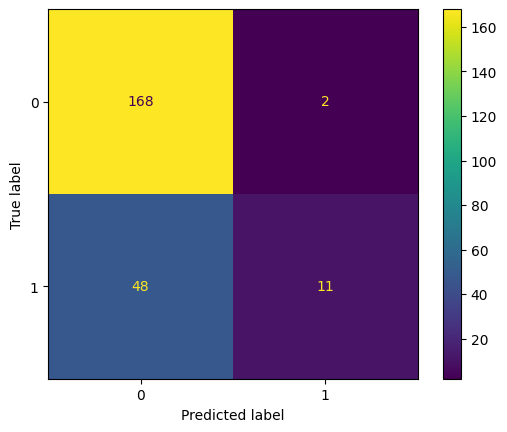

In [30]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot();

#### ROC Curve and AUC Curve

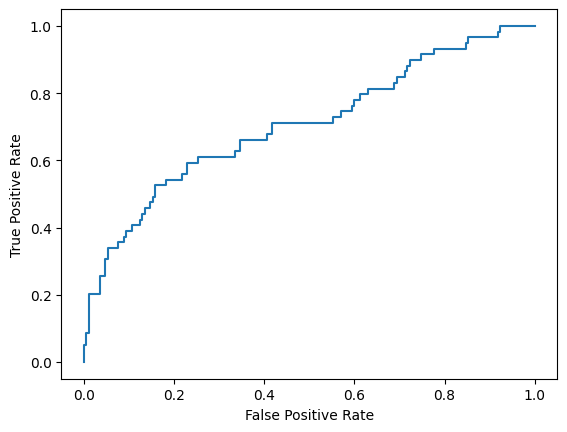

In [31]:
fpr, tpr, _ = sklearn.metrics.roc_curve(y_test, y_pred_prob[:,1])
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr).plot()

In [32]:
# AUC score
AUC = sklearn.metrics.roc_auc_score(y_test, y_pred_prob[:,1])
print("Area under ROC curve: ", AUC)

Area under ROC curve:  0.7057826520438685


### Visualize trees and feature importance

#### Example tree from all of Random Forests

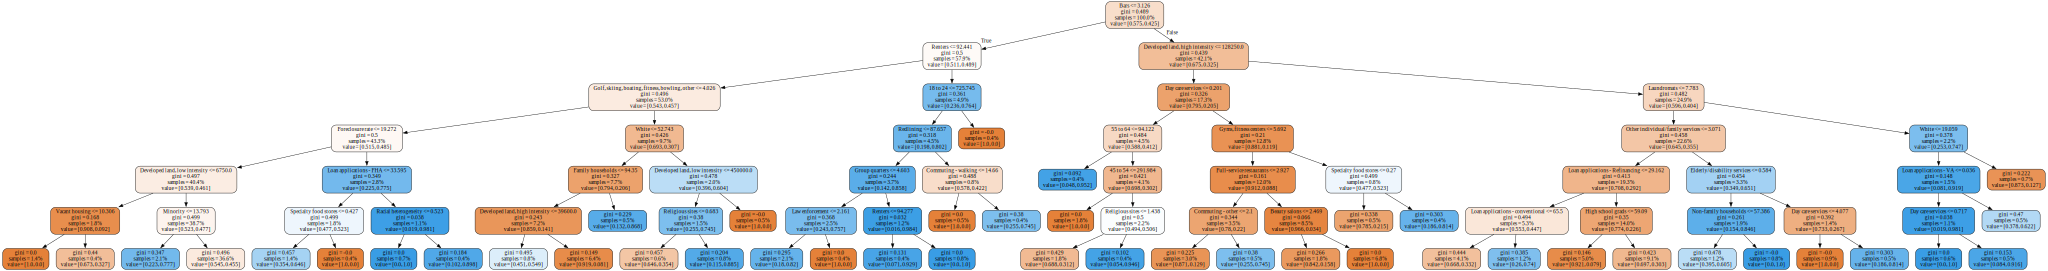

In [33]:
# Export the first three decision trees from the forest
tree = rand_search.best_estimator_.estimators_[5]
dot_data = export_graphviz(tree,
                           feature_names=X_train.columns,  
                           filled=True,  
                           impurity=True,
                           rotate=False,
#                            class_names=False,
                           rounded=True,
#                            max_depth=2,
                           fontname='times new roman',
                           proportion=True)
graph = graphviz.Source(dot_data)
display(graph)

#### Feature importance scores

Text(0.5, 1.0, 'Importance Score of Features in Predicting Gentrification')

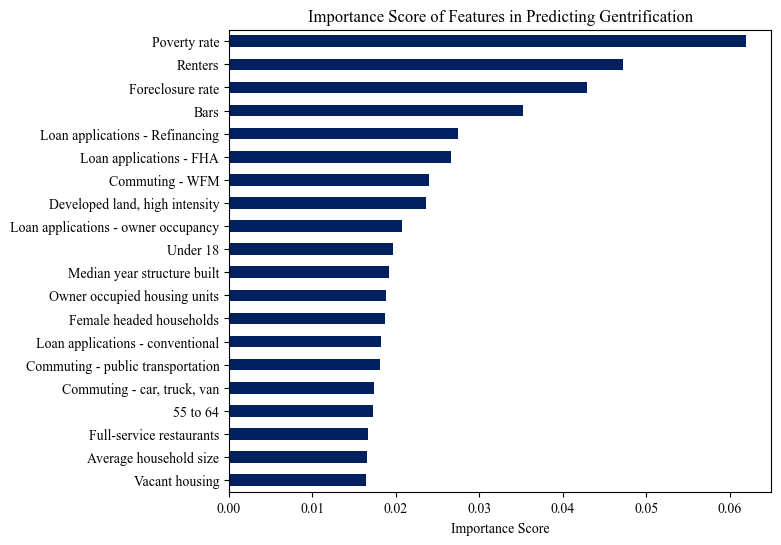

In [34]:
# Create a series containing feature importances from the model and feature names from the training data
feature_importances = pd.Series(rand_search.best_estimator_.feature_importances_, index=X_train.columns).sort_values(ascending=False)
most_imp = feature_importances[0:20]
reverse_imp = most_imp.iloc[::-1]

# Plot a simple bar chart
csfont = {'fontname':'Times New Roman'}
plt.rcParams["figure.figsize"] = (7, 6)
plt.rcParams["font.family"] = "Times New Roman"
chart = reverse_imp.plot.barh(color = ["#002060"])
chart.set_xlabel('Importance Score', **csfont)
chart.set_title('Importance Score of Features in Predicting Gentrification', **csfont)
# reverse_imp.plot.text()


#### Change in feature importance scores across all variables considered

Text(0.5, 1.0, 'Importance of Features in Predicting Gentrification')

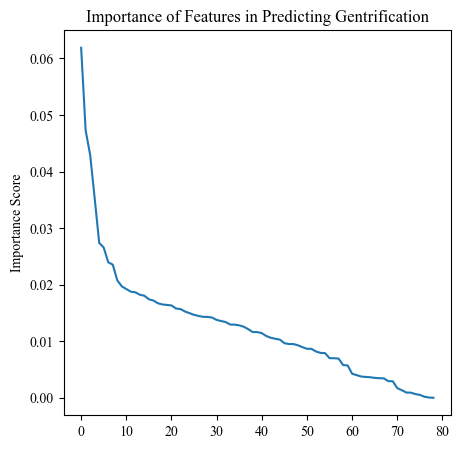

In [35]:
# chart of importance over features
plt.rcParams["figure.figsize"] = (5, 5)
its = [i for i in range(0, len(feature_importances))]
plt.plot(its, feature_importances)
plt.ylabel('Importance Score')
plt.title('Importance of Features in Predicting Gentrification')

#### See features importances in list form

In [52]:
feature_importances[40:60]

White                                             0.011433
Group quarters                                    0.010916
Average work commute                              0.010611
Population density                                0.010434
Hispanic                                          0.010284
Non-family households                             0.009656
65 and older                                      0.009507
Other individual/family services                  0.009497
Developed land, medium intensity                  0.009287
Beauty salons                                     0.008944
Limited service (fast food)                       0.008668
Family households                                 0.008648
Housing units                                     0.008186
Occupied housing units                            0.007938
Commuting - other                                 0.007893
Golf, skiing, boating, fitness, bowling, other    0.007009
Loan applications - VA                            0.0069

### Save model predictions for gentrification in 2010-2013 period to plot in R

In [53]:
# make list of all predicted values
y_pred_train = rand_search.best_estimator_.predict(X_train)
all_preds = np.append(y_pred_train, y_pred)

# append model predictions to original 2000 data
data_2000['Gentrified - Model'] = all_preds

# # save file (to be mapped in R)
data_2000.to_csv('2010_gentrified_model.csv', index=False)

### Make and save predictions for future based on 2010-2013 data

In [54]:
# get prediction variables
y_pred_future = rand_search.best_estimator_.predict(x_2010)

# append to original 2010 data
data_2010['Gentrified'] = y_pred_future

# save file (to be mapped in R)
data_2010.to_csv('future_gentrified_model.csv', index=False)